#EDA and Data Cleaning Notebook
##Project: Voice-Based Health Classification
###Author: [Christopher Mauro]

##Project Overview

This project focuses on analyzing a dataset of audio-derived features extracted from voice recordings of individuals categorized as either Healthy or Unhealthy. The objective is to explore how measurable vocal characteristics—such as Mel-frequency coefficients, spectral properties, and energy-based metrics—can be used to understand differences in vocal health. Through exploratory data analysis, data cleaning, visualization, and predictive modeling, the project aims to identify key acoustic indicators of vocal impairment and develop a model capable of classifying a speaker’s health status based on their voice features.

##Dataset Description

· File: VowelA_High_latest.csv

· Columns:

 *  Audio features: chroma_stft, rmse, spectral_centroid, spectral_bandwidth, rolloff, zero_crossing_rate, mfcc1 to mfcc20

 *  Metadata: filename, ID, G (gender: 'm' or 'w'), A (age)

 *  Target variable: label ("Healthy" or "Unhealthy")

##Setup and Data Loading

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading Dataset
df = pd.read_csv('/content/VowelA_High_latest.csv')

##Initial Data Inspection

In [3]:
#Preview Data
df.head()

,Unnamed: 0,filename,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,...,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label,ID,G,A
0,0,1-a_h.wav,0.127341,0.355538,1587.507015,2002.198851,2737.971816,0.066798,-233.566208,48.504421,...,-28.190628,1.143172,4.134034,52.794827,39.092403,49.037060,Healthy,1,w,20
1,1,10-a_h.wav,0.215317,0.250342,1272.900724,1850.302841,1692.919922,0.043325,-179.419601,119.705742,...,7.790230,-7.037875,-9.193601,11.183559,-2.173607,-9.420938,Healthy,10,w,22
2,2,100-a_h.wav,0.212512,0.251419,919.203795,1014.718104,1275.967478,0.047079,-209.186188,167.135651,...,-20.040691,-4.153456,-2.725145,-10.669723,-2.336876,7.741264,Healthy,100,m,66
3,3,1000-a_h.wav,0.198861,0.157396,1119.517351,1529.490600,1501.657586,0.045487,-210.244278,139.819519,...,-0.163550,7.797343,-26.314997,-6.622046,0.535120,0.749695,Healthy,1000,m,31
4,4,1002-a_h.wav,0.370113,0.143538,1060.678054,1346.299507,1524.942294,0.050109,-175.039948,181.905212,...,-20.939833,13.306650,-26.597456,-8.324528,10.786009,-6.677513,Healthy,1002,m,25


In [4]:
#Dataset Summary Statistics
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())

Dataset Shape: (2035, 32)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2035 entries, 0 to 2034
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2035 non-null   int64  
 1   filename            2035 non-null   object 
 2   chroma_stft         2035 non-null   float64
 3   rmse                2035 non-null   float64
 4   spectral_centroid   2035 non-null   float64
 5   spectral_bandwidth  2035 non-null   float64
 6   rolloff             2035 non-null   float64
 7   zero_crossing_rate  2035 non-null   float64
 8   mfcc1               2035 non-null   float64
 9   mfcc2               2035 non-null   float64
 10  mfcc3               2035 non-null   float64
 11  mfcc4               2035 non-null   float64
 12  mfcc5               2035 non-null   float64
 13  mfcc6               2035 non-null   float64
 14  mfcc7               2035 non-null   float64
 15  mfcc8         

##Data Cleaning

In [5]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0            0
filename              0
chroma_stft           0
rmse                  0
spectral_centroid     0
spectral_bandwidth    0
rolloff               0
zero_crossing_rate    0
mfcc1                 0
mfcc2                 0
mfcc3                 0
mfcc4                 0
mfcc5                 0
mfcc6                 0
mfcc7                 0
mfcc8                 0
mfcc9                 0
mfcc10                0
mfcc11                0
mfcc12                0
mfcc13                0
mfcc14                0
mfcc15                0
mfcc16                0
mfcc17                0
mfcc18                0
mfcc19                0
mfcc20                0
label                 0
ID                    0
G                     0
A                     0
dtype: int64


In [6]:
#Check for Invalid or Inconsistent Data in Categorical Columns
print("\nGender Column")
print(df['G'].value_counts())
df = df[df['G'].isin(['m', 'w'])]

print("\nLabel Column")
print(df['label'].value_counts())
df = df[df['label'].isin(['Healthy', 'Unhealthy'])]


Gender Column
G
w    1155
m     880
Name: count, dtype: int64

Label Column
label
Unhealthy    1348
Healthy       687
Name: count, dtype: int64


In [7]:
#Check for Unrealistic Values
print(df['A'].describe())
df = df[(df['A'] >= 0) & (df['A'] <= 100)]

count    2035.000000
mean       42.735135
std        18.136219
min         9.000000
25%        24.000000
50%        42.000000
75%        59.000000
max        94.000000
Name: A, dtype: float64


In [8]:
#Make sure all 'ID' rows are unique
#Drop any duplicates
print(df['ID'].nunique() == len(df))
df = df.drop_duplicates(subset=['ID'])
print("Filename Pattern Check:", df['filename'].str.match(r'\d+-a_h\.wav').all())

True
Filename Pattern Check: True


In [9]:
#Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'filename', 'ID'])

In [10]:
# Verify updated columns
print("Updated Columns:\n", df.columns)

Updated Columns:
 Index(['chroma_stft', 'rmse', 'spectral_centroid', 'spectral_bandwidth',
       'rolloff', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4',
       'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11',
       'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18',
       'mfcc19', 'mfcc20', 'label', 'G', 'A'],
      dtype='object')


In [11]:
#Create CSV file of cleaned data
df.to_csv('Cleaned_VowelA_High_latest.csv', index=False)

##EDA & Visualization

In [12]:
#Updated Dataset Summary Statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       chroma_stft         rmse  spectral_centroid  spectral_bandwidth  \
count  2035.000000  2035.000000        2035.000000         2035.000000   
mean      0.226609     0.192420        1316.674901         1684.033835   
std       0.065532     0.064474         401.289370          434.532199   
min       0.120402     0.015067         566.319248          830.011306   
25%       0.182932     0.147187        1056.073776         1376.519591   
50%       0.213884     0.186241        1233.786591         1592.463814   
75%       0.251294     0.231145        1468.926577         1905.480356   
max       0.614178     0.463574        4295.111712         3403.279259   

           rolloff  zero_crossing_rate        mfcc1        mfcc2        mfcc3  \
count  2035.000000         2035.000000  2035.000000  2035.000000  2035.000000   
mean   2092.416751            0.054684  -204.067168   126.722018   -22.393496   
std    1243.021777            0.020236    46.305767    30.334038 

In [13]:
#Simplify MFCC Features for Visualization
df['mean_mfcc'] = df[[f'mfcc{i}' for i in range(1, 21)]].mean(axis=1)
df['std_mfcc'] = df[[f'mfcc{i}' for i in range(1, 21)]].std(axis=1)

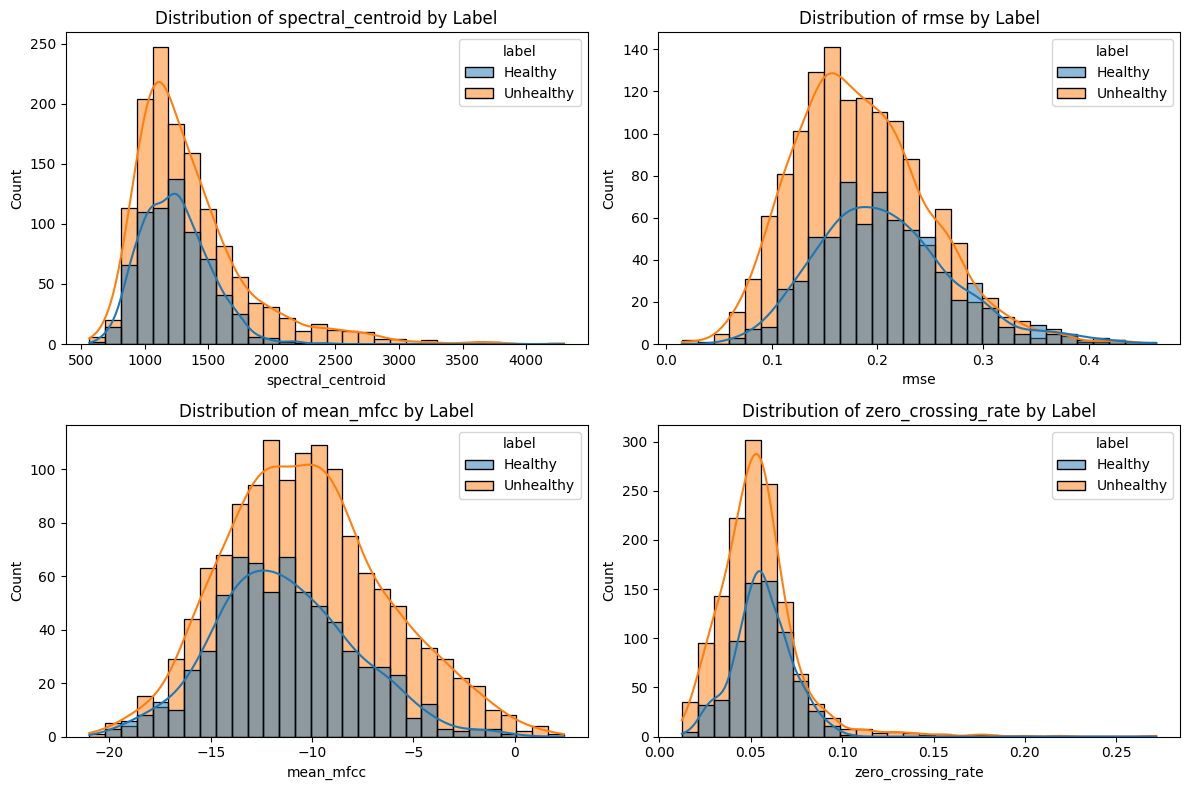

In [14]:
#Histogram of Key Audio Features

# Select key features for visualization
key_features = ['spectral_centroid', 'rmse', 'mean_mfcc', 'zero_crossing_rate']

# Plot histograms
plt.figure(figsize=(12, 8))
for i, feature in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=feature, hue='label', bins=30, kde=True)
    plt.title(f'Distribution of {feature} by Label')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Health Status by Gender')

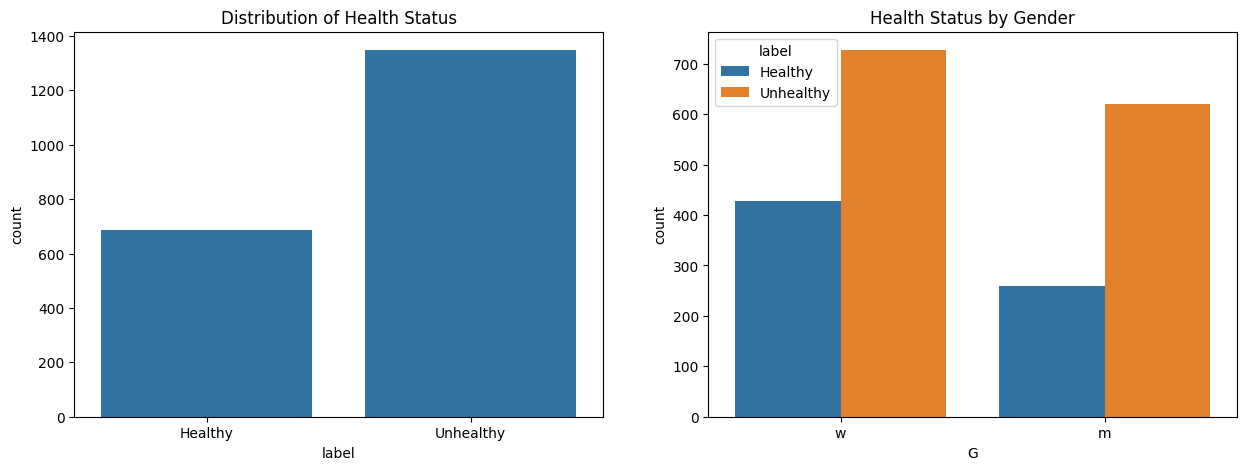

In [34]:
#Bar Charts of Health Distribution

# Chart For Data-wide Distribution
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='label', data=df)
plt.title('Distribution of Health Status')

# Chart for Distribution by Gender
plt.subplot(1, 2, 2)
sns.countplot(x='G', hue='label', data=df)
plt.title('Health Status by Gender')

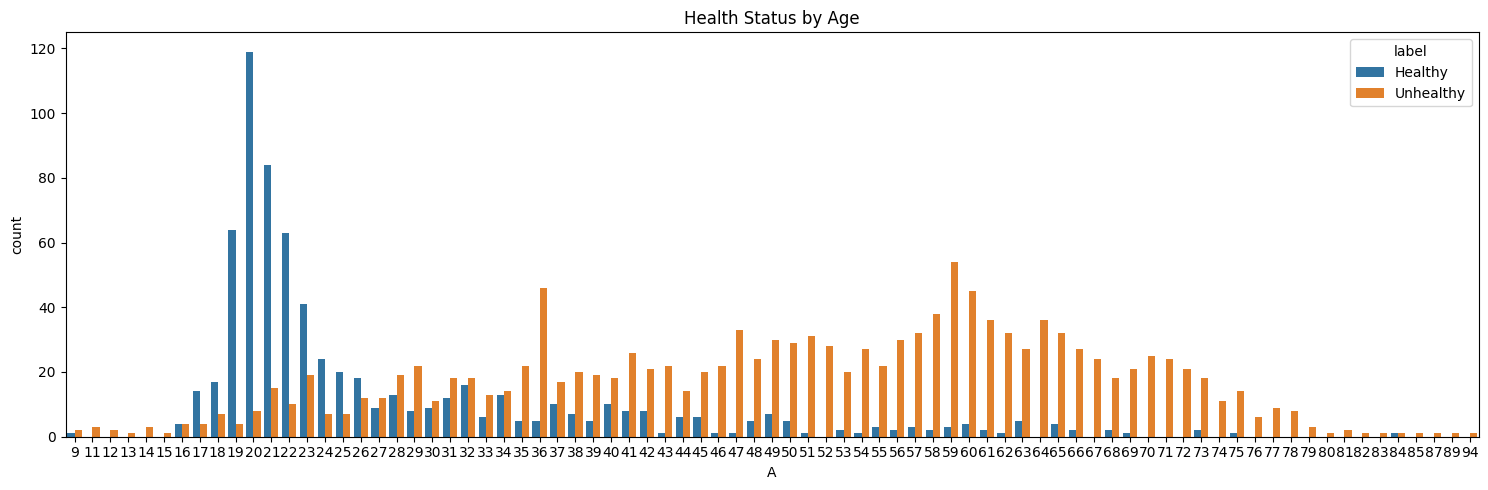

In [35]:
#Bar Charts for Distribution Continued

# Chart for Distribution by Age
plt.figure(figsize=(15, 5))
sns.countplot(x='A', hue='label', data=df)
plt.title('Health Status by Age')
plt.tight_layout()
plt.show()

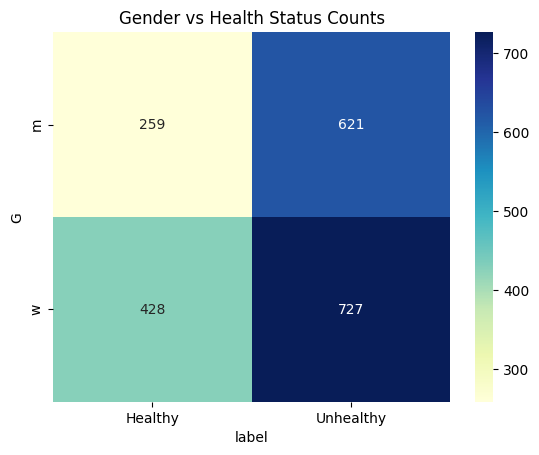

In [40]:
#Different Visualization for above Box Chart on Gender Distribution

# Plot Heatmap
gender_health = df.pivot_table(index='G', columns='label', aggfunc='size', fill_value=0)
sns.heatmap(gender_health, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Gender vs Health Status Counts')
plt.show()

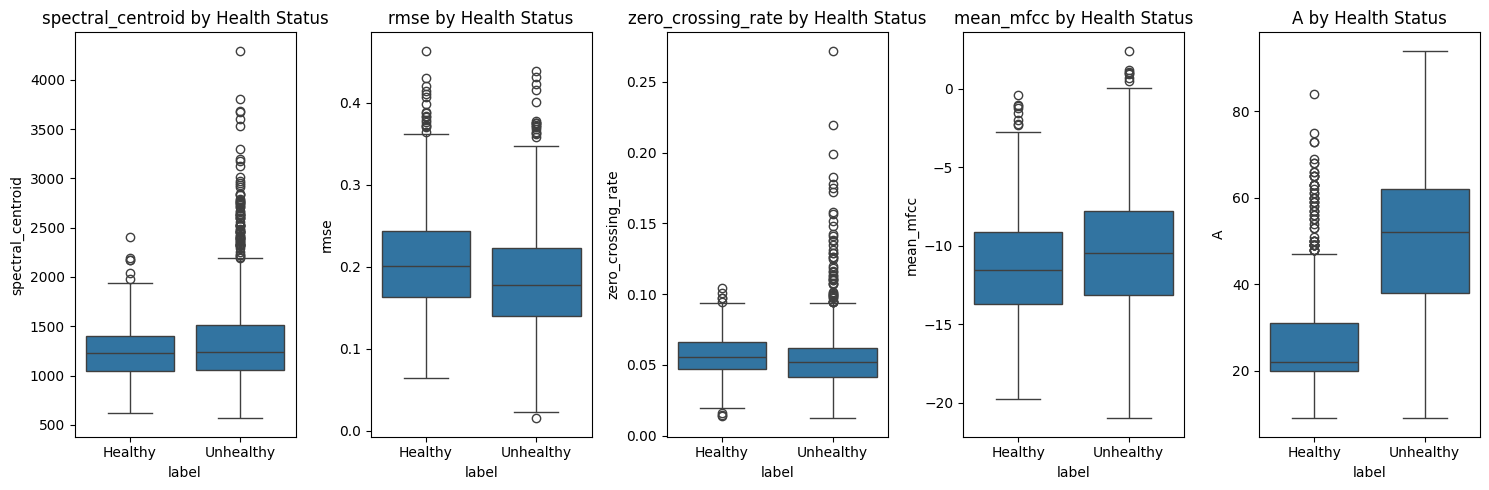

In [16]:
#Box Plots of Key Audio Features

# Box Plots
plt.figure(figsize=(15, 5))
features = ['spectral_centroid', 'rmse', 'zero_crossing_rate', 'mean_mfcc', 'A']
for i, feature in enumerate(features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(x='label', y=feature, data=df)
    plt.title(f'{feature} by Health Status')
plt.tight_layout()
plt.show()

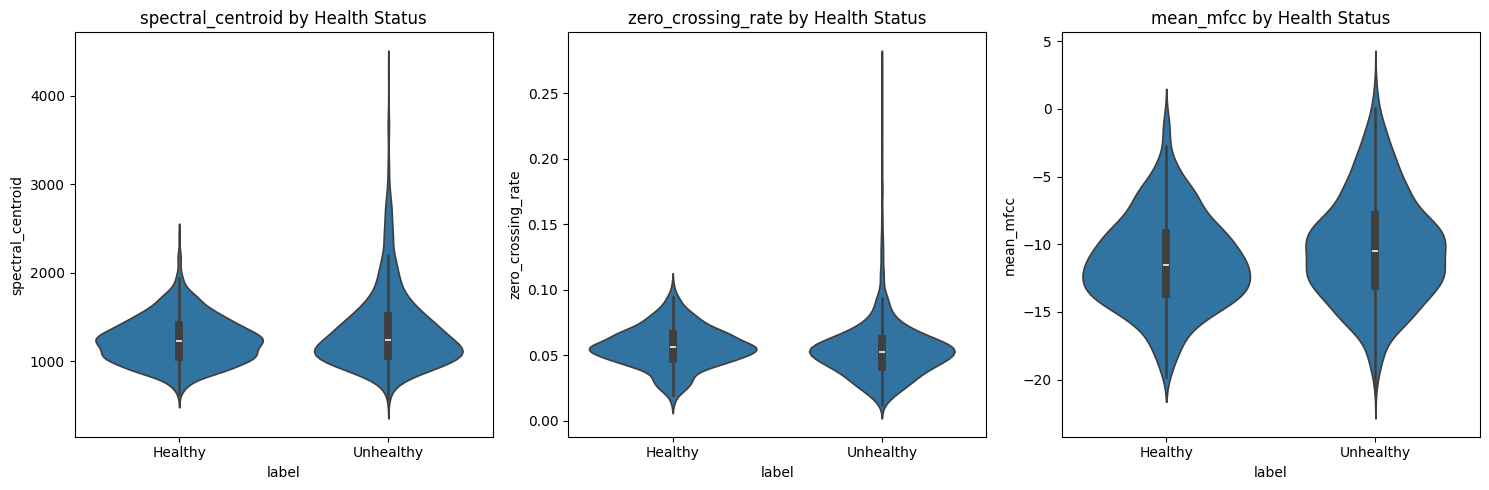

In [18]:
#Violin Plots for Key Audio Features

# Violin Plots
plt.figure(figsize=(15, 5))
features = ['spectral_centroid', 'zero_crossing_rate', 'mean_mfcc']
for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x='label', y=feature, data=df)
    plt.title(f'{feature} by Health Status')
plt.tight_layout()
plt.show()

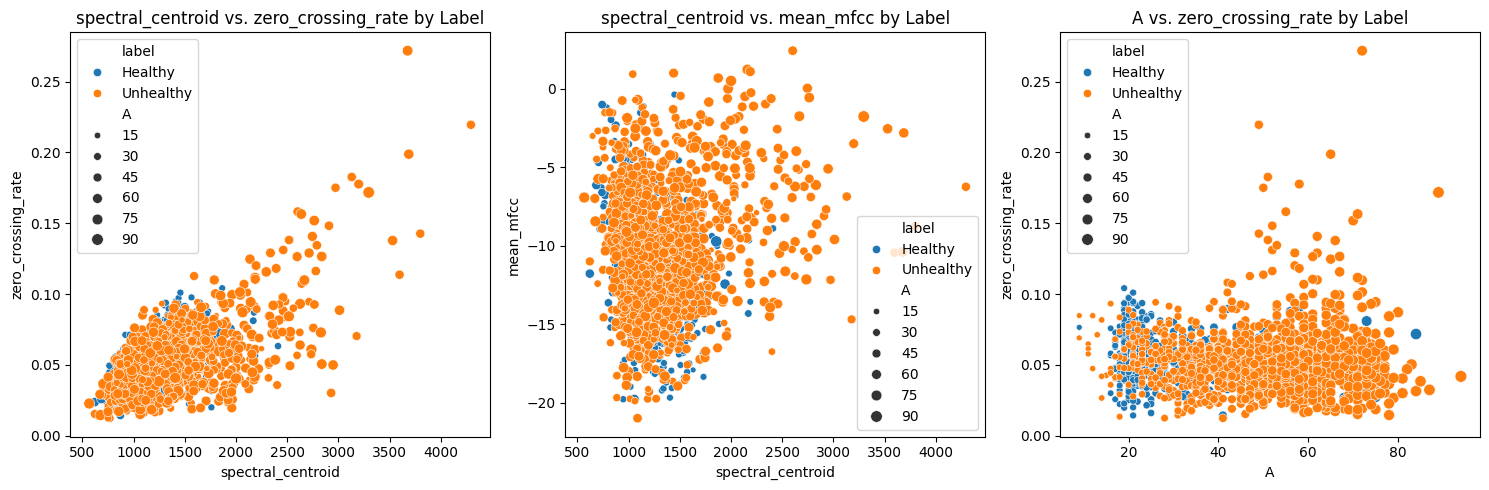

In [17]:
#Scatter Plots for Key Audio Features by Label and Age

#Scatter Plots
plt.figure(figsize=(15, 5))
pairs = [('spectral_centroid', 'zero_crossing_rate'), ('spectral_centroid', 'mean_mfcc'), ('A', 'zero_crossing_rate')]
for i, (x, y) in enumerate(pairs, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=x, y=y, hue='label', size='A', data=df)
    plt.title(f'{x} vs. {y} by Label')
plt.tight_layout()
plt.show()

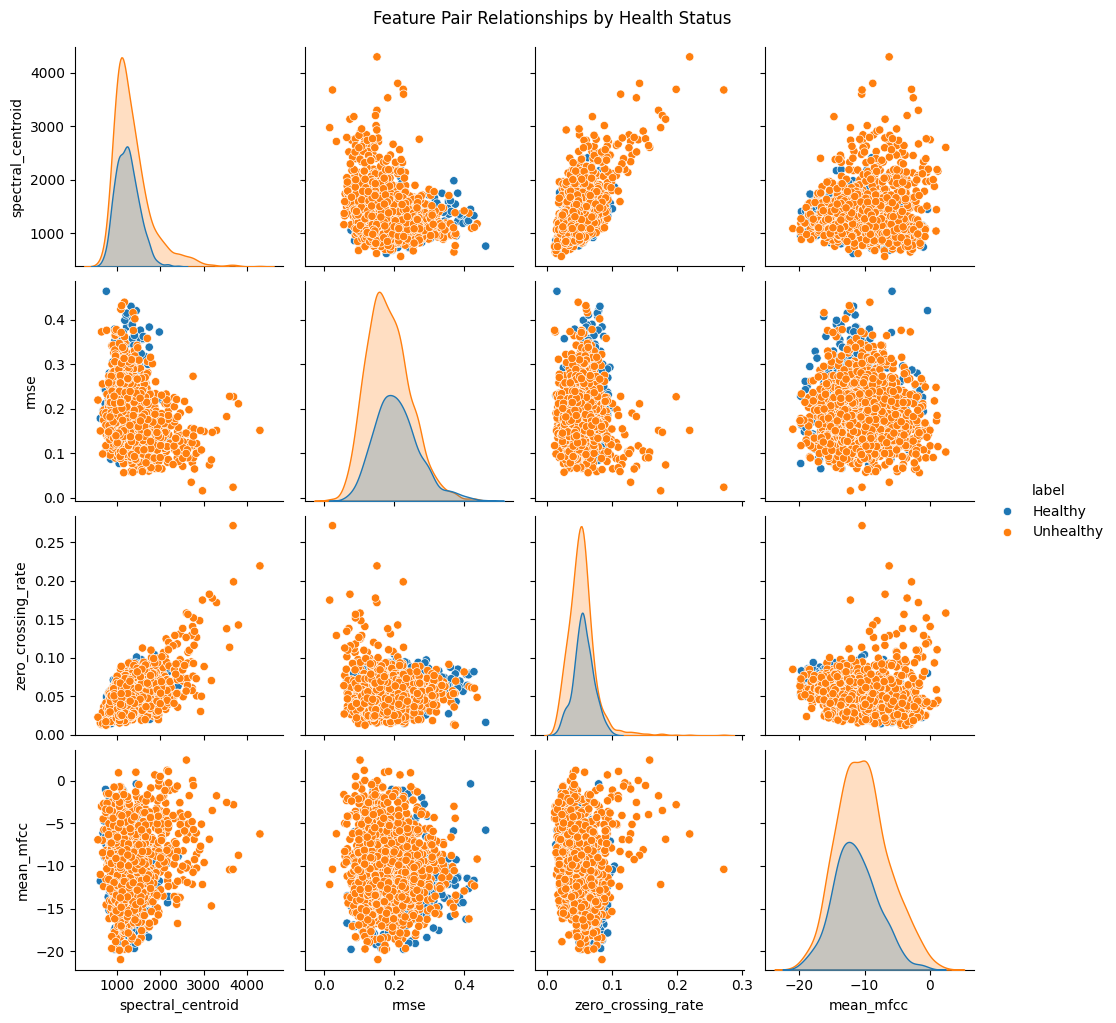

In [21]:
#Pairplot for Feature Relationships

# Pairplot
selected_features = ['spectral_centroid', 'rmse', 'zero_crossing_rate', 'mean_mfcc']
sns.pairplot(df, vars=selected_features, hue='label', diag_kind='kde')
plt.suptitle("Feature Pair Relationships by Health Status", y=1.02)
plt.show()

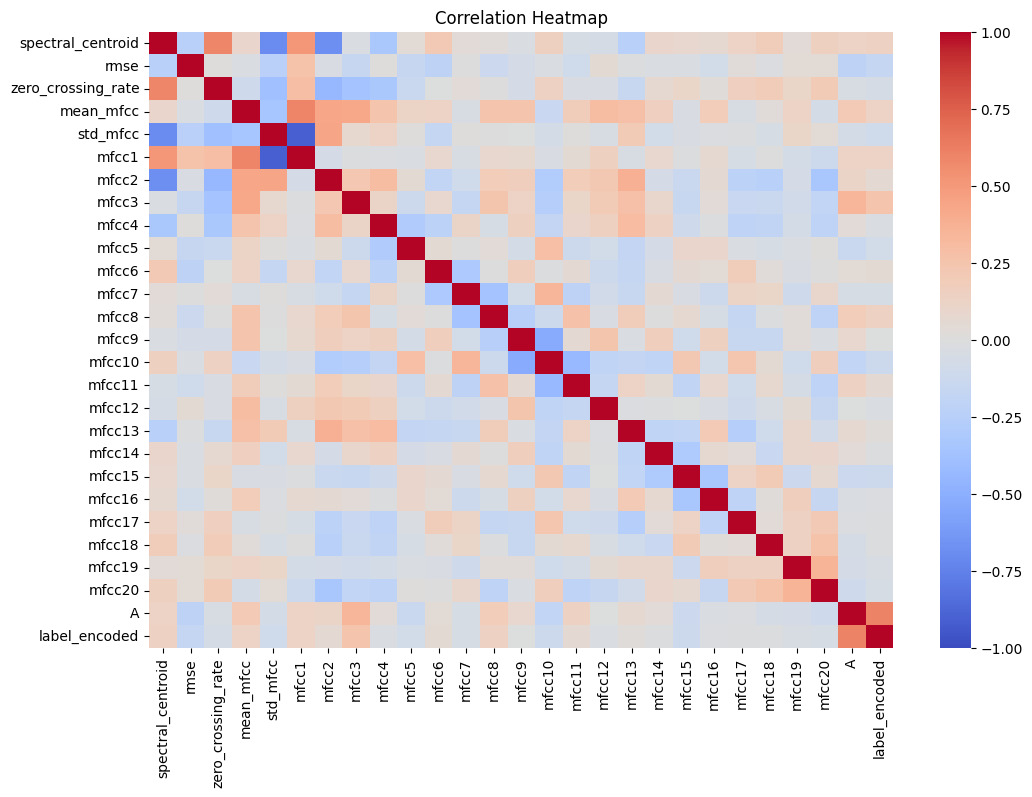

In [42]:
#Correlation Heatmap for Key Audio Features and Health Status

# Plot Heatmap
df['label_encoded'] = df['label'].map({'Healthy': 0, 'Unhealthy': 1})
numeric_cols = ['spectral_centroid', 'rmse', 'zero_crossing_rate', 'mean_mfcc', 'std_mfcc'] + [f'mfcc{i}' for i in range(1, 21)] + ['A']
plt.figure(figsize=(12, 8))
corr = df[numeric_cols + ['label_encoded']].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

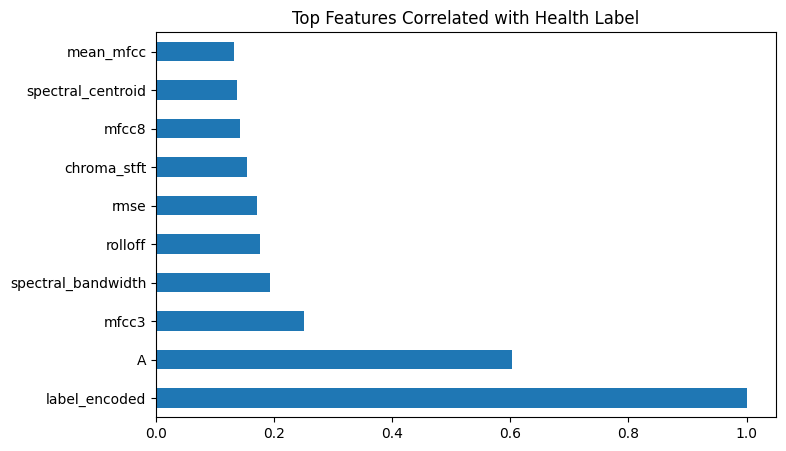

In [44]:
#Top Key Features

# Bar Chart
corr = df.corr(numeric_only=True)['label_encoded'].abs().sort_values(ascending=False)
top_corr = corr.head(10)
top_corr.plot(kind='barh', figsize=(8,5), title='Top Features Correlated with Health Label')
plt.show()

##Insights

1. Data Overview

* The dataset includes audio-derived voice features such as spectral_centroid, rmse, zero_crossing_rate, and mfcc1–mfcc20, along with metadata (age, gender, label).

* The target variable, label, represents two categories: Healthy and Unhealthy voices.

* No critical missing values were found, and categorical variables were cleaned (gender standardized as 'm' and 'w').

2. Health Status Distribution

* Countplots showed that Healthy and Unhealthy samples are moderately balanced, though Healthy voices slightly dominate.

* This means the dataset can support classification modeling without extreme resampling but stratified splits should be used to preserve balance.

3. Gender Distribution by Health Status

* Both genders are represented, but the Gender Proportion Heatmap revealed:

* A slightly higher proportion of unhealthy cases among male speakers, suggesting potential gender-linked vocal strain patterns or demographic imbalance.

* However, this imbalance is not extreme — gender can be treated as an auxiliary variable rather than a primary predictor.

4. Feature Distributions by Health Status

* Spectral Centroid: Unhealthy voices tend to have lower centroid values, indicating diminished high-frequency energy and duller timbre — a known sign of vocal fold irregularity.

* RMSE (Root Mean Square Energy): Shows higher variance among Unhealthy voices, implying unstable vocal intensity.

* Zero Crossing Rate: Unhealthy samples often exhibit slightly higher average ZCR, suggesting noisier phonation or breathiness.

* Mean MFCC: Subtle shifts were observed between classes — lower mean MFCC in Unhealthy voices often corresponds to weaker formant structures.

* Age: Overlaps across classes, but some increase in Unhealthy cases with higher ages, reflecting potential age-related voice deterioration.

5. Pairplot (Feature Relationships)

* The Pairplot revealed partial clustering of Healthy and Unhealthy samples, particularly when combining spectral_centroid with rmse or mean_mfcc.

* While not completely separable, the trends suggest nonlinear class boundaries — indicating that ensemble or kernel-based models (like Random Forest) may outperform linear ones.

* Features like zero_crossing_rate and rmse show curved separations, supporting this nonlinear relationship.

6. Feature Interaction (Scatter Plots)

* Scatter plots between (spectral_centroid, zero_crossing_rate) and (mean_mfcc, spectral_centroid) confirm that Unhealthy voices cluster in lower centroid–higher ZCR regions, reinforcing earlier inferences.

* When age is encoded as point size, older unhealthy voices cluster more densely, showing mild correlation between age and vocal irregularity.

7. Correlation Heatmap

* Correlations among MFCCs were strongly positive, as expected — they capture related frequency components.

* spectral_centroid and zero_crossing_rate had moderate correlation with each other but weak correlation with most MFCCs, implying complementary features.

* Correlation of the encoded target (label_encoded) with individual features was modest ( |r| ≈ 0.2–0.4), confirming that no single feature dominates classification — combinations will yield stronger predictive power.

8. Top Correlated Features (Target Analysis)

* The Top Feature Correlation chart highlighted that:

* mfcc1, mfcc4, spectral_centroid, and rmse had the strongest relationships with the health label.

* MFCCs in the middle range (mfcc6–mfcc10) contributed less, possibly representing less distinctive harmonics.

* This supports using feature selection or dimensionality reduction to improve model focus.

9. Summary of Key Insights

| Observation | Interpretation | Impact |
| -------- | -------- | -------- |
| Healthy vs Unhealthy moderately balanced| Fair dataset for supervised learning | No major resampling needed|
| Slight male bias in Unhealthy group| Possible demographic skew | Control for gender in analysis |
| Lower spectral centroid, higher ZCR in Unhealthy | Reduced brightness and noisier phonation | Key features for classification
| RMSE variability higher in Unhealthy | Unstable vocal energy | Good indicator of pathology
| MFCC1–4 and spectral features correlate most with target | Dominant frequency envelope differences | Useful for model feature selection
| Nonlinear feature boundaries (Pairplot) | Complex relationships between acoustic features | Suggests tree-based or kernel models

##Conclusion

The exploratory data analysis of the Voice-Based Health Classification dataset provided meaningful insights into the acoustic and demographic factors influencing vocal health. Through statistical summaries and visualizations, several important patterns emerged.

Healthy and Unhealthy samples were relatively balanced, enabling robust modeling without major class imbalance concerns. Gender and age distributions revealed minor biases—males showed slightly higher rates of vocal irregularity, and older individuals tended to cluster within the Unhealthy category—though these effects were not dominant.

Feature analysis highlighted clear acoustic distinctions between Healthy and Unhealthy voices. Unhealthy samples generally exhibited lower spectral centroid values (indicating reduced high-frequency content), greater energy variability (RMSE), and higher zero-crossing rates, all consistent with noisier and less stable phonation. MFCC-based features, particularly the first few coefficients (MFCC1–MFCC4), showed the strongest correlations with health status, reinforcing their importance in representing timbral and harmonic structure.

Correlation analysis confirmed moderate relationships between certain spectral features and the health label, but no single variable dominated classification potential—suggesting that multivariate, nonlinear models (such as Random Forest or XGBoost) will likely perform best. The addition of pairplots and feature-correlation charts further supported this conclusion, revealing curved and overlapping boundaries that traditional linear methods may not fully capture.